In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matlab.engine

from glob import glob

import sys
sys.path.append('../../wavelet/')
import wavelet_funcs as wf

import os
from scipy.ndimage import gaussian_filter

In [3]:
sys.path.append('../../../../2024_Kidney_Empagliflozin/Analysis/pylibs/')
import normalize, misc

import pandas as pd

df = pd.read_csv('../../../../2024_Kidney_Empagliflozin/ZDF_ExperimentNotes_Empagliflozin - Acute_Empa_ExperimentTimes.csv')
meta = pd.read_csv('../../../../2024_Kidney_Empagliflozin/ZDF_ExperimentNotes_Empagliflozin - Acute_Empa_GeneralMetadata.csv')

In [5]:
eng = matlab.engine.start_matlab()

### Load some data

In [13]:
treatment = 'Empa'
paths = glob(f'../../../../2024_Kidney_Empagliflozin/Analysis/Register_translation_single_vessels/2024*_{treatment.lower()}/*TimeSeries.nc')

# paths = [p for p in paths if '20241011b' not in p] # Few Time stamps vary by magnitude of 0.5 s in this dataset. In all other datasets, time step varies by 1e-4
# paths = paths[:2] + paths[100:102]

In [15]:
p = paths[50]

In [17]:
ds = xr.open_dataset(p)
x = ds.tlsc_xymean**(-2)

rat = os.path.basename(p)[:9]
vessel_id = int(os.path.basename(p).split('vessel')[-1].split('_')[0])
t_inject_ = np.round(misc.get_injection_time(df, rat, treatment)/0.5)*0.5 # Rounded to 0.5, so the resulting time values aligned 0.5

In [18]:
dt = 0.5
Fs = 2
t = np.arange(x.size)*dt
x = x.data

In [23]:
eng.workspace["x"] = matlab.double(x.astype(float).reshape(-1, 1).tolist())
eng.workspace["Fs"] = float(Fs)

eng.eval(
"""
fb = cwtfilterbank(SignalLength=numel(x),...
    SamplingFrequency=Fs,...
    Wavelet="Morse",...
    TimeBandwidth=30,...
    FrequencyLimits=[0.005, 0.1],...
    VoicesPerOctave=16);

[cfs,f,coi] = cwt(x, FilterBank=fb);

amp = abs(cfs);
""",
nargout=0)

amp = np.array(eng.workspace["amp"])
freq = np.array(eng.workspace["f"]).squeeze()
coi  = np.array(eng.workspace["coi"]).squeeze()
scales = np.asarray(eng.eval("fb.scales")).squeeze()

print(amp.shape)

(70, 3569)


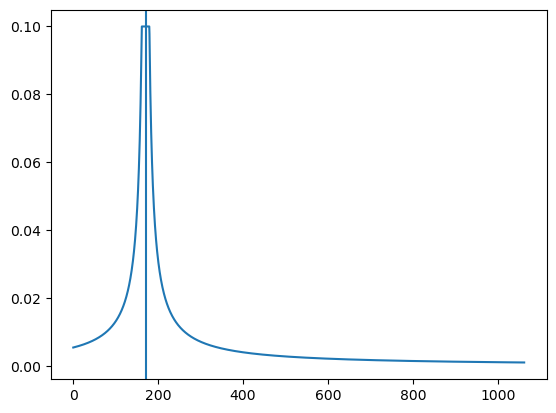

In [27]:
mask_l = t<t_inject_
coi_l = coi[mask_l]
t_l = t[mask_l]

mask_r = (t<t.mean())
coi_r = coi[mask_r]
t_r = t[mask_r]


coi_injection = np.hstack((coi_l[::-1], coi_r))
t_coi_injection = t[:coi_injection.size]

plt.plot(t_coi_injection, coi_injection)
plt.axvline(t_inject_)

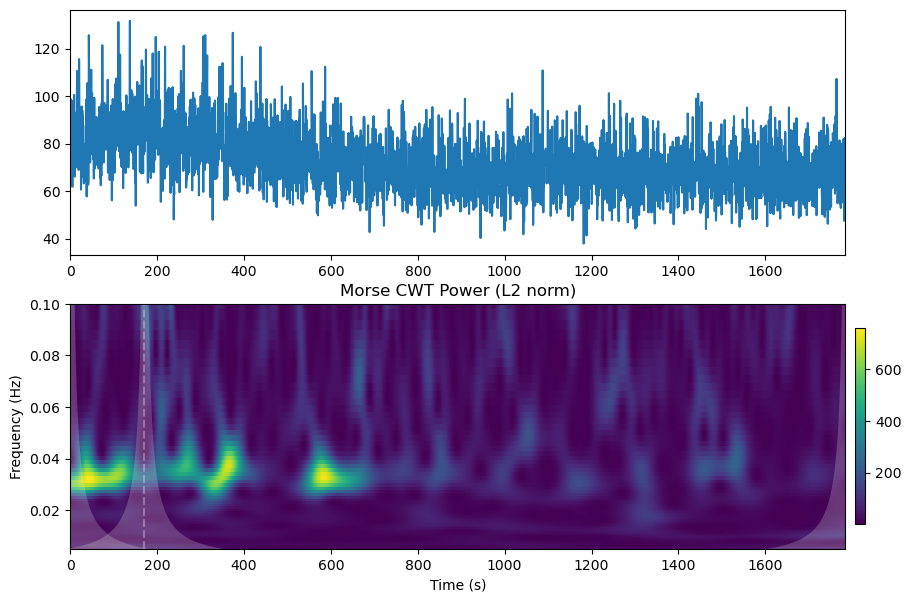

In [35]:
f, (ax0, ax) = plt.subplots(2,1,figsize=(10,7))
ax0.plot(t,x)
# wf.plot_cwt(amp, freq, t, add_colorbar=True, ax=ax)
wf.plot_cwt((amp**2)*scales.reshape((scales.size, 1)), freq, t, add_colorbar=True, ax=ax)

ax.fill_between(t, y1=coi, color='w', alpha=0.2, lw=0)
ax.fill_between(t_coi_injection, coi_injection,color='w', alpha=0.2, lw=0)
ax.axvline(t_inject_, color='w', ls='--', alpha=0.3)

ax.set_ylim([freq.min(), freq.max()])
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Power (L2 norm)")

ax0.set_xlim(ax.get_xlim())
# plt.savefig('test.jpg', dpi=600, bbox_inches='tight')

In [77]:
eng.quit()